<a href="https://colab.research.google.com/github/sarkarpragati/Machine-Learning-Lab/blob/main/Polynomial_Regression_%26_SVM_Decision_Boundary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Polynomial Regression**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/Online_Learning_Behavior_Dataset_Worldwide.csv')

In [ ]:
np.random.seed(42)
X = np.random.uniform(-3, 3, 50).reshape(-1, 1)
y = 0.5 * X**3 - X**2 + 2 * X + np.random.normal(0, 3, X.shape)

In [ ]:
degree = 3
poly_features = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly_features.fit_transform(X)

In [ ]:
model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

In [ ]:
X_sorted = np.sort(X, axis=0)
X_sorted_poly = poly_features.transform(X_sorted)
y_pred = model.predict(X_sorted_poly)

In [ ]:

y_train_pred = model.predict(X_poly)
mse = mean_squared_error(y, y_train_pred)
r2 = r2_score(y, y_train_pred)

In [ ]:
print(f"Polynomial Degree: {degree}")
print(f"Mean Squared Error: {mse:.3f}")
print(f"R² Score: {r2:.3f}")

Polynomial Degree: 3
Mean Squared Error: 7.357
R² Score: 0.913


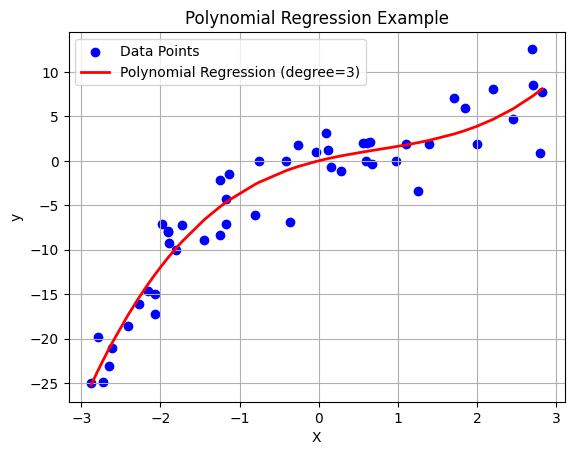

In [ ]:
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X_sorted, y_pred, color='red', linewidth=2, label=f'Polynomial Regression (degree={degree})')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression Example")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
class LinearSVR:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, epsilon=0.1, n_iters=1000):
        """
        Initialize SVR parameters.
        :param learning_rate: Step size for gradient descent
        :param lambda_param: Regularization strength
        :param epsilon: Epsilon-insensitive margin
        :param n_iters: Number of iterations for training
        """
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.epsilon = epsilon
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        """
        Train the SVR model using gradient descent.
        :param X: Feature matrix (n_samples, n_features)
        :param y: Target values (n_samples,)
        """
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            y_pred = np.dot(X, self.w) + self.b
            errors = y_pred - y

            grad_w = np.zeros(n_features)
            grad_b = 0

            for i in range(n_samples):
                if errors[i] > self.epsilon:
                    grad_w += X[i]
                    grad_b += 1
                elif errors[i] < -self.epsilon:
                    grad_w -= X[i]
                    grad_b -= 1


            self.w -= self.lr * (grad_w + self.lambda_param * self.w)
            self.b -= self.lr * grad_b

    def predict(self, X):
        """
        Make predictions using the trained SVR model.
        :param X: Feature matrix (n_samples, n_features)
        :return: Predicted target values (n_samples,)
        """
        return np.dot(X, self.w) + self.b


Weights: [4.06582756]
Bias: 5.400000000000033


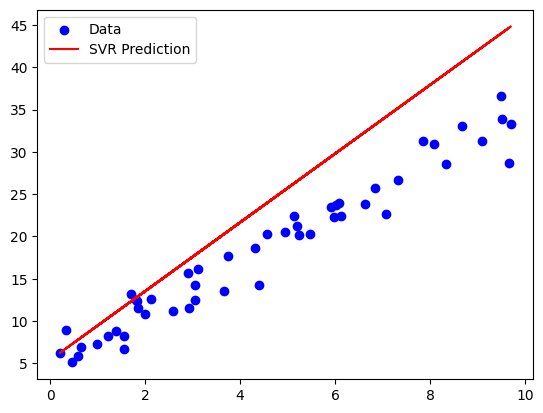

In [ ]:
if __name__ == "__main__":

    np.random.seed(42)
    X = np.random.rand(50, 1) * 10
    y = 3 * X.squeeze() + 5 + np.random.randn(50) * 2

    svr = LinearSVR(learning_rate=0.01, lambda_param=0.1, epsilon=0.5, n_iters=2000)
    svr.fit(X, y)

    y_pred = svr.predict(X)

    print("Weights:", svr.w)
    print("Bias:", svr.b)

    try:
        import matplotlib.pyplot as plt
        plt.scatter(X, y, color='blue', label='Data')
        plt.plot(X, y_pred, color='red', label='SVR Prediction')
        plt.legend()
        plt.show()
    except ImportError:
        print("matplotlib not installed, skipping plot.")

**SVM Decision Boundary**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
X, y = datasets.make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.5)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
svm_clf = SVC(kernel='linear', C=1.0, random_state=42)
svm_clf.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
y_pred = svm_clf.predict(X_test)

In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[37  0]
 [ 0 23]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        23

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

Accuracy: 1.0


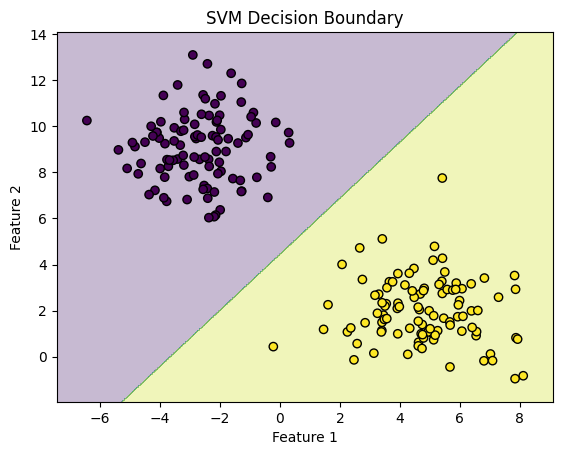

In [ ]:
def plot_decision_boundary(clf, X, y):

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.title("SVM Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()
plot_decision_boundary(svm_clf, X, y)